Este cuaderno se enfoca en la carga, limpieza inicial de la base de datos de la NBA, análisis de correlaciones y distribuciones de las estadísticas clave sin utilizar gráficos de caja.

Dimensiones originales: (8768, 31)


,year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,...,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV,PTS_PER_MIN
0,2020-21,Playoffs,203109.0,21.0,Jae Crowder,1.610613e+09,PHX,22.0,729.0,76.0,...,41.0,19.0,18.0,19.0,67.0,237.0,318.0,2.16,1.00,0.325103
1,2018-19,Regular%20Season,1626210.0,481.0,Alan Williams,1.610613e+09,BKN,5.0,26.0,8.0,...,3.0,1.0,0.0,1.0,2.0,18.0,33.0,3.00,1.00,0.692308
2,2014-15,Regular%20Season,202366.0,370.0,Jerome Jordan,1.610613e+09,BKN,44.0,383.0,50.0,...,13.0,8.0,15.0,22.0,58.0,138.0,207.0,0.59,0.36,0.360313
3,2018-19,Playoffs,200768.0,9.0,Kyle Lowry,1.610613e+09,TOR,24.0,900.0,122.0,...,159.0,31.0,7.0,54.0,96.0,361.0,450.0,2.94,0.57,0.401111
4,2018-19,Regular%20Season,2733.0,318.0,Shaun Livingston,1.610613e+09,GSW,64.0,967.0,109.0,...,114.0,31.0,27.0,38.0,74.0,258.0,397.0,3.00,0.82,0.266805


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8768 entries, 0 to 8767
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         8721 non-null   object 
 1   Season_type  8727 non-null   object 
 2   PLAYER_ID    8721 non-null   float64
 3   RANK         8727 non-null   float64
 4   PLAYER       8768 non-null   object 
 5   TEAM_ID      8727 non-null   float64
 6   TEAM         8768 non-null   object 
 7   GP           8713 non-null   float64
 8   MIN          8721 non-null   float64
 9   FGM          8725 non-null   float64
 10  FGA          8735 non-null   float64
 11  FG_PCT       8721 non-null   float64
 12  FG3M         8725 non-null   float64
 13  FG3A         8722 non-null   float64
 14  FG3_PCT      8721 non-null   float64
 15  FTM          8724 non-null   float64
 16  FTA          8724 non-null   float64
 17  FT_PCT       8722 non-null   float64
 18  OREB         8729 non-null   float64
 19  DREB  

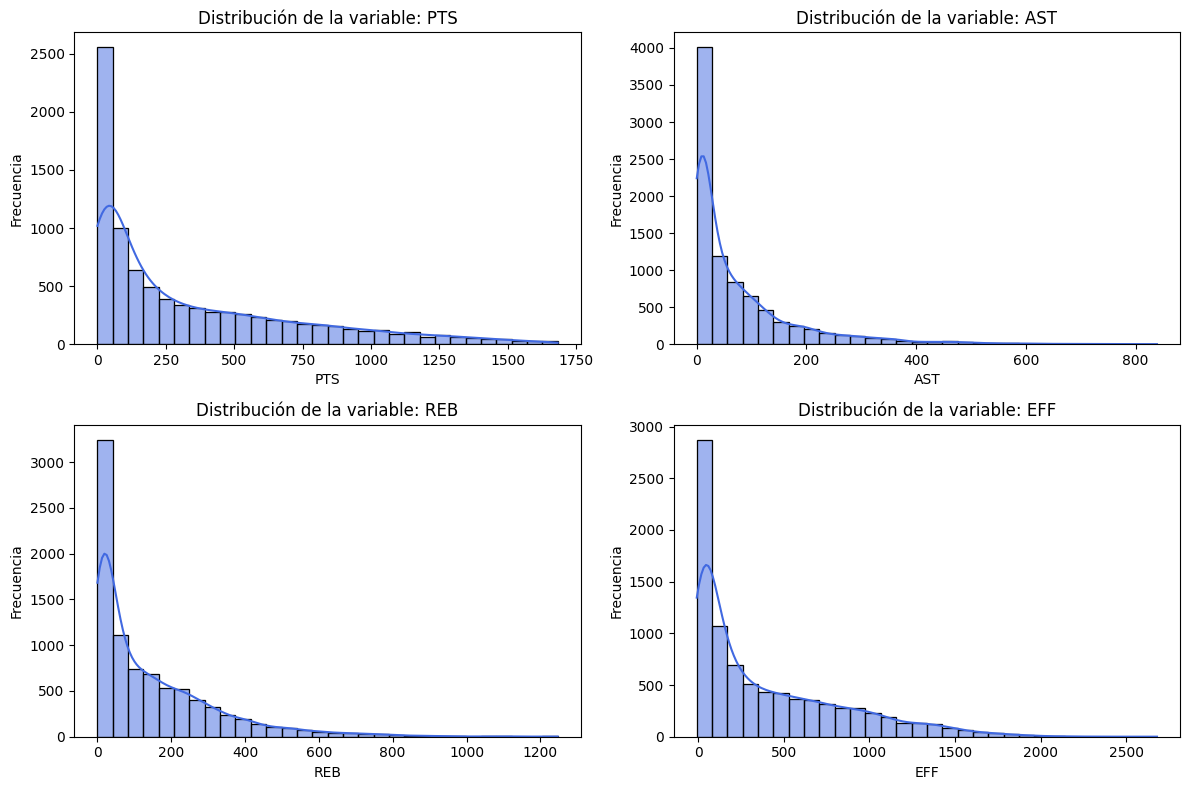

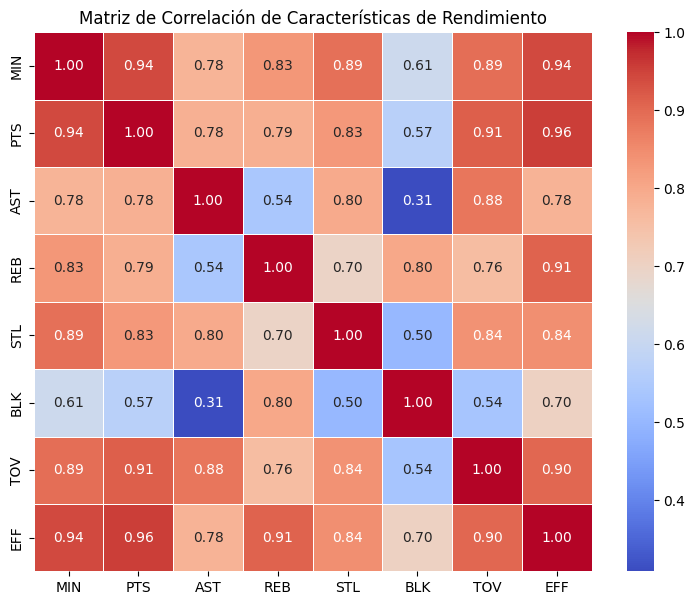

In [3]:
# Celda 1: Importación de librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Celda 2: Carga del dataset original y revisión inicial
df = pd.read_csv('nba_10000_processed.csv')
print("Dimensiones originales:", df.shape)
display(df.head())
print(df.info())

# Celda 3: Preprocesamiento y Limpieza
# Seleccionamos las columnas numéricas clave de rendimiento y la variable objetivo
cols_features = ['MIN', 'PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'EFF', 'Season_type']
df_clean = df.dropna(subset=cols_features).copy()

# Guardar el dataset limpio para los siguientes cuadernos
df_clean.to_csv('nba_clean.csv', index=False)
print("Dataset limpio exportado correctamente como 'nba_clean.csv'. Dimensiones finales:", df_clean.shape)

# Celda 4: Visualización de Distribuciones (Histogramas con curvas KDE)
plt.figure(figsize=(12, 8))
metrics_to_plot = ['PTS', 'AST', 'REB', 'EFF']
for i, col in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i+1)
    sns.histplot(df_clean[col], kde=True, bins=30, color='royalblue')
    plt.title(f'Distribución de la variable: {col}')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Celda 5: Análisis de Correlación (Mapa de calor)
plt.figure(figsize=(9, 7))
numeric_cols = ['MIN', 'PTS', 'AST', 'REB', 'STL', 'BLK', 'TOV', 'EFF']
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Características de Rendimiento')
plt.show()